In [2]:
import pandas as pd 
import seaborn as sns 

#chargement des data-set
data1=pd.read_csv('passages_1_heures_complet.csv')
data2=pd.read_csv('passages_2_heures_complet.csv')
data3=pd.read_csv('passages_3_heures_complet.csv')
data4=pd.read_csv('passages_2_minutes_complet.csv')
data5=pd.read_csv('passages_5_heures_complet.csv')
data6=pd.read_csv('passages_6_heures_complet.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_28764\3739448168.py:5: DtypeWarning: Columns (3,20,23,32,35,44,47,56,59,68,71,80,83,92,95,104,107,116,119,128,131,140,143,164,167,176,179,188,191,200,203,212,215,224,227,236,237,240,249,252,261,264,273,274,277,298,301,310,313,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,368,369,371,372,373,374,375,376,377,379,380,382,383,384,385,386,387,389,390,392,393,394,395,396,397,398,399,401,402,404,405,406,407,408,409,410,411,413,414,416,417,418,419,420,421,422,423,425,426,428,429,430,431,432,433,434,435,437,438,440,441,442,443,444,445,446,448,449,451,452,453,454,455,456,458,459,461,462,463,464,465,466,467,468,470,471,473,474,475,476,477,478,479,480,482,483,485,486,487,488,489,490,491,492,494,495,497,498,499,500,501,502,503,504,506,507,509,510,511,512,513,514,515,516,518,519,521,522,523,524,525,526,527,528,530,531,533,534,535,536,537,538,539,540,542,543,545,546,547,548,549,550,551,552,554,555,557

In [ ]:
#chargement des données 
df1=pd.DataFrame(data1)
df2=pd.DataFrame(data2)
df3=pd.DataFrame(data3)
df4=pd.DataFrame(data4)
df5=pd.DataFrame(data5)
df6=pd.DataFrame(data6)

In [ ]:
colonnes_a_supprimer = [
    col for col in data.columns
    if col.startswith("vehicle_EstimatedCalls_EstimatedCall_")
    or col == "vehicle_JourneyNote_0_value"
]

data_nettoye = data.drop(columns=colonnes_a_supprimer, errors="ignore")

In [4]:
# 2) Fonction de nettoyage
def nettoyer_dataframe(df):
    colonnes_a_supprimer = [
        col for col in df.columns
        if col.startswith("vehicle_EstimatedCalls_EstimatedCall_")
        or col == "vehicle_JourneyNote_0_value"
    ]
    
    df_nettoye = df.drop(columns=colonnes_a_supprimer, errors="ignore")
    return df_nettoye

# 3) Appliquer le nettoyage à tous les DataFrames
df1_nettoye = nettoyer_dataframe(df1)
df2_nettoye = nettoyer_dataframe(df2)
df3_nettoye = nettoyer_dataframe(df3)
df4_nettoye = nettoyer_dataframe(df4)
df5_nettoye = nettoyer_dataframe(df5)
df6_nettoye = nettoyer_dataframe(df6)

# 4) Compiler tous les DataFrames en un seul dataset
dataset_final = pd.concat(
    [df1_nettoye, df2_nettoye, df3_nettoye, df4_nettoye, df5_nettoye, df6_nettoye],
    ignore_index=True
)

# 5) Vérification
print(dataset_final.shape)
print(dataset_final.head())

(892446, 26)
      call_AimedArrivalTime   call_AimedDepartureTime  \
0  2026-03-20T17:26:34.000Z  2026-03-20T17:27:04.000Z   
1  2026-03-20T16:56:31.000Z  2026-03-20T16:57:26.000Z   
2  2026-03-20T17:13:50.000Z  2026-03-20T17:14:25.000Z   
3  2026-03-20T17:10:46.000Z  2026-03-20T17:11:41.000Z   
4  2026-03-20T17:06:23.000Z  2026-03-20T17:06:58.000Z   

  call_ArrivalPlatformName_value call_ArrivalProximityText_value  \
0                              1                             NaN   
1                             1A                             NaN   
2                              1                             NaN   
3                              1                             NaN   
4                              1                             NaN   

  call_ArrivalStatus call_ArrivalStopAssignment_ExpectedQuayRef_value  \
0            ON_TIME                         STIF:StopPoint:Q:473930:   
1            ON_TIME                         STIF:StopPoint:Q:473993:   
2            ON_

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# =========================================================
# 1) CHARGEMENT DES FICHIERS
# =========================================================

trafic = dataset_final
arret = pd.read_csv("arrets.csv", sep=";", encoding="utf-8", low_memory=False)

print("Colonnes arret :")
print(arret.columns.tolist())

# =========================================================
# 2) RENOMMER LES COLONNES DE TRAFIC
# =========================================================

colonnes_fr = {
    "Unnamed: 0": "index_ligne",
    "call_AimedArrivalTime": "heure_arrivee_theorique_appel",
    "call_AimedDepartureTime": "heure_depart_theorique_appel",
    "call_ArrivalPlatformName_value": "quai_arrivee",
    "call_ArrivalProximityText_value": "proximite_arrivee",
    "call_ArrivalStatus": "statut_arrivee",
    "call_ArrivalStopAssignment_ExpectedQuayRef_value": "ref_quai_arrivee",
    "call_DeparturePlatformName_value": "quai_depart",
    "call_DepartureStatus": "statut_depart",
    "call_DepartureStopAssignment_ExpectedQuayRef_value": "ref_quai_depart",
    "call_DestinationDisplay_0_value": "destination_appel",
    "call_ExpectedArrivalTime": "heure_arrivee_estimee",
    "call_ExpectedDepartureTime": "heure_depart_estimee",
    "call_StopPointRef_value": "ref_arret_api",
    "date_requete": "date_requete",
    "vehicle_DatedVehicleJourneyRef_value": "ref_course_datee",
    "vehicle_DestinationName_0_value": "destination_vehicule",
    "vehicle_DestinationRef_value": "ref_stop_area_destination",
    "vehicle_DirectionRef_value": "direction",
    "vehicle_LineRef_value": "ref_ligne",
    "vehicle_OriginName_0_value": "origine_vehicule",
    "vehicle_OriginRef_value": "ref_stop_area_origine",
    "vehicle_PublishedLineName_0_value": "nom_public_ligne",
    "vehicle_RecordedAtTime": "date_enregistrement_vehicule",
    "vehicle_VehicleFeatureRef_0": "caracteristique_vehicule",
    "vehicle_VehicleJourneyName_0_value": "nom_course_vehicule",
    "vehicle_VehicleMode_0": "mode_vehicule",
    "delay": "retard"
}

trafic = trafic.rename(columns=colonnes_fr)

# =========================================================
# 3) RENOMMER LES COLONNES UTILES DE arret
# =========================================================

arret = arret.rename(columns={
    "ArRId": "id_arret",
    "ArRName": "nom_arret_ref",
    "ArRTown": "ville_arret_ref",
    "ZdAId": "id_stop_area"
})

for col in ["id_arret", "id_stop_area"]:
    if col in arret.columns:
        arret[col] = pd.to_numeric(arret[col], errors="coerce")

# =========================================================
# 4) EXTRAIRE LATITUDE / LONGITUDE DEPUIS ArGeopoint
# =========================================================

if "ArRGeopoint" not in arret.columns:
    raise KeyError("La colonne 'ArGeopoint' est introuvable dans arrets.csv")

geo = arret["ArRGeopoint"].astype(str).str.extract(
    r"^\s*([-+]?\d*\.?\d+)\s*,\s*([-+]?\d*\.?\d+)\s*$"
)

arret["latitude"] = pd.to_numeric(geo[0], errors="coerce")
arret["longitude"] = pd.to_numeric(geo[1], errors="coerce")

# =========================================================
# 5) EXTRAIRE LES IDS DES ZONES D'ARRÊT
# =========================================================

trafic["id_stop_area_depart"] = (
    trafic["ref_stop_area_origine"]
    .astype(str)
    .str.extract(r"STIF:StopArea:SP:(\d+):", expand=False)
)

trafic["id_stop_area_arrivee"] = (
    trafic["ref_stop_area_destination"]
    .astype(str)
    .str.extract(r"STIF:StopArea:SP:(\d+):", expand=False)
)

trafic["id_stop_area_depart"] = pd.to_numeric(trafic["id_stop_area_depart"], errors="coerce")
trafic["id_stop_area_arrivee"] = pd.to_numeric(trafic["id_stop_area_arrivee"], errors="coerce")

# =========================================================
# 6) CRÉER UNE TABLE DES COORDONNÉES PAR ZONE
# x = longitude, y = latitude
# =========================================================

zones = (
    arret.groupby("id_stop_area", as_index=False)
    .agg({
        "longitude": "mean",
        "latitude": "mean"
    })
)

# =========================================================
# 7) AJOUTER LES COORDONNÉES DU DÉPART
# =========================================================

trafic = trafic.merge(
    zones.rename(columns={
        "id_stop_area": "id_stop_area_depart",
        "longitude": "x_depart",
        "latitude": "y_depart"
    }),
    on="id_stop_area_depart",
    how="left"
)

# =========================================================
# 8) AJOUTER LES COORDONNÉES DE L’ARRIVÉE
# =========================================================

trafic = trafic.merge(
    zones.rename(columns={
        "id_stop_area": "id_stop_area_arrivee",
        "longitude": "x_arrivee",
        "latitude": "y_arrivee"
    }),
    on="id_stop_area_arrivee",
    how="left"
)

# =========================================================
# 9) CONVERSION DES DATES
# =========================================================

colonnes_dates = [
    "heure_arrivee_theorique_appel",
    "heure_depart_theorique_appel",
    "heure_arrivee_estimee",
    "heure_depart_estimee",
    "date_requete",
    "date_enregistrement_vehicule"
]

for col in colonnes_dates:
    if col in trafic.columns:
        trafic[col] = pd.to_datetime(trafic[col], errors="coerce", utc=True)

# =========================================================
# 10) VARIABLES TEMPORELLES
# =========================================================

if "date_requete" in trafic.columns:
    trafic["annee_requete"] = trafic["date_requete"].dt.year
    trafic["mois_requete"] = trafic["date_requete"].dt.month
    trafic["jour_requete"] = trafic["date_requete"].dt.day
    trafic["heure_requete"] = trafic["date_requete"].dt.hour
    trafic["minute_requete"] = trafic["date_requete"].dt.minute
    trafic["jour_semaine_requete"] = trafic["date_requete"].dt.dayofweek

# =========================================================
# 11) ENCODAGE
# =========================================================

colonnes_a_ne_pas_encoder = {
    "ref_arret_api",
    "ref_stop_area_destination",
    "ref_stop_area_origine",
    "ref_ligne",
    "ref_course_datee"
}

colonnes_objet = trafic.select_dtypes(include=["object"]).columns.tolist()
colonnes_a_encoder = [c for c in colonnes_objet if c not in colonnes_a_ne_pas_encoder]

for col in colonnes_a_encoder:
    trafic[col] = trafic[col].fillna("manquant").astype(str)
    le = LabelEncoder()
    trafic[col + "_encode"] = le.fit_transform(trafic[col])

# =========================================================
# 12) SAUVEGARDE
# =========================================================

trafic.to_csv("trafic_nettoye.csv", index=False, encoding="utf-8-sig")

print("Fichier créé : trafic_nettoye.csv")
print("Dimensions :", trafic.shape)

pd.set_option("display.max_columns", None)
print(
    trafic[[
        "ref_stop_area_origine",
        "id_stop_area_depart",
        "x_depart",
        "y_depart",
        "ref_stop_area_destination",
        "id_stop_area_arrivee",
        "x_arrivee",
        "y_arrivee"
    ]].head(10)
)

Colonnes arret :
['ArRId', 'ArRVersion', 'ArRCreated', 'ArRChanged', 'ArRName', 'ArRType', 'ArRXEpsg2154', 'ArRYEpsg2154', 'ArRTown', 'ArRPostalRegion', 'ArRAccessibility', 'ArRAudibleSignals', 'ArRVisualSigns', 'ArRFareZone', 'ZdAId', 'ArRGeopoint']
Fichier créé : trafic_nettoye.csv
Dimensions : (892446, 53)
     ref_stop_area_origine  id_stop_area_depart  x_depart   y_depart  \
0  STIF:StopArea:SP:43198:                43198  2.095047  48.898755   
1  STIF:StopArea:SP:43198:                43198  2.095047  48.898755   
2  STIF:StopArea:SP:43198:                43198  2.095047  48.898755   
3  STIF:StopArea:SP:43198:                43198  2.095047  48.898755   
4  STIF:StopArea:SP:43198:                43198  2.095047  48.898755   
5  STIF:StopArea:SP:43198:                43198  2.095047  48.898755   
6  STIF:StopArea:SP:43198:                43198  2.095047  48.898755   
7  STIF:StopArea:SP:43198:                43198  2.095047  48.898755   
8  STIF:StopArea:SP:43198:               

In [ ]:
import pandas as pd

data=pd.read_csv('trafic_nettoye.csv')
df8=pd.DataFrame(data)

dataset = pd.DataFrame()
dataset["x_depart"] = df8['x_depart']
dataset["y_depart"] = df8["y_depart"]
dataset["x_arrivee"] = df8["x_arrivee"]
dataset["y_arrivee"] = df8["y_arrivee"]
dataset["gare_depart"] = df8["destination_appel"]
dataset["gare_arrive"] = df8["origine_vehicule"]
dataset["quai_depart"] = df8["quai_depart"]
dataset["quai_arrivee"] = df8["quai_arrivee"]
dataset["direction"] = df8["direction"]
dataset["statut_depart"] = df8["statut_depart"]
dataset["statut_arrivee"] = df8["statut_arrivee"]
dataset["date_requete"] = df8["date_requete"]
dataset["heure_arrivee_theorique_appel"]=df8["heure_arrivee_theorique_appel"]
dataset["heure_depart_theorique_appel"]=df8["heure_depart_theorique_appel"]
dataset["heure_arrivee_estimee"]=df8["heure_arrivee_estimee"]
dataset["heure_depart_estimee"]=df8["heure_arrivee_estimee"]

dataset["nom_public_ligne"]=df8["nom_public_ligne"]
dataset["caracteristique_vehicule"]=df8["caracteristique_vehicule"]
dataset["nom_course_vehicule"]=df8["nom_course_vehicule"]


	

# 5. Afficher le résultat
print(dataset)

        x_depart   y_depart  x_arrivee  y_arrivee    gare_depart  \
0       2.095047  48.898755   2.655201  48.839724          Torcy   
1       2.095047  48.898755   2.655201  48.839724          Torcy   
2       2.095047  48.898755   2.655201  48.839724          Torcy   
3       2.095047  48.898755   2.655201  48.839724          Torcy   
4       2.095047  48.898755   2.655201  48.839724          Torcy   
...          ...        ...        ...        ...            ...   
892441  2.782527  48.869770   2.011573  49.048233  Cergy le Haut   
892442  2.782527  48.869770   2.011573  49.048233  Cergy le Haut   
892443  2.782527  48.869770   2.011573  49.048233  Cergy le Haut   
892444  2.782527  48.869770   2.011573  49.048233  Cergy le Haut   
892445  2.782527  48.869770   2.011573  49.048233  Cergy le Haut   

                   gare_arrive quai_depart quai_arrivee direction  \
0        Saint-Germain-en-Laye           1            1     Aller   
1        Saint-Germain-en-Laye          1A   

In [12]:
# Lignes totalement dupliquées
duplicates = dataset[dataset.duplicated()]
print("Nombre de lignes dupliquées :", duplicates.shape[0])

# Afficher les doublons
print(duplicates)

Nombre de lignes dupliquées : 144
       x_depart   y_depart  x_arrivee  y_arrivee             gare_depart  \
6268   2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   
6271   2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   
6277   2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   
6278   2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   
6279   2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   
...         ...        ...        ...        ...                     ...   
14088  2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   
14089  2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   
14090  2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   
14091  2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   
14092  2.095047  48.898755   2.782527   48.86977  Marne-la-Vallée Chessy   

                 gare_arrive quai_depart quai_arrivee

In [16]:
dataset.iloc[0]

x_depart                                          2.095047
y_depart                                         48.898755
x_arrivee                                         2.655201
y_arrivee                                        48.839724
gare_depart                                          Torcy
gare_arrive                          Saint-Germain-en-Laye
quai_depart                                              1
quai_arrivee                                             1
direction                                            Aller
statut_depart                                      ON_TIME
statut_arrivee                                     ON_TIME
date_requete                     2026-03-20 17:07:05+00:00
heure_arrivee_theorique_appel    2026-03-20 17:26:34+00:00
heure_depart_theorique_appel     2026-03-20 17:27:04+00:00
heure_arrivee_estimee            2026-03-20 17:26:34+00:00
heure_depart_estimee             2026-03-20 17:26:34+00:00
nom_public_ligne                                        

In [13]:
dataset['statut_arrivee'].unique()

array(['ON_TIME', 'ARRIVED', 'CANCELLED', 'DELAYED'], dtype=object)

In [15]:
dataset['statut_arrivee'].value_counts()

statut_arrivee
ON_TIME      754875
DELAYED      128514
ARRIVED        8712
CANCELLED       345
Name: count, dtype: int64

In [14]:
dataset.describe()

,x_depart,y_depart,x_arrivee,y_arrivee
count,892446.000000,892446.000000,892446.000000,892446.000000
mean,2.381378,48.882534,2.375619,48.881056
std,0.318865,0.078150,0.314521,0.077691
min,2.011573,48.752173,2.011573,48.752173
25%,2.095047,48.869770,2.095047,48.869770
50%,2.504498,48.869770,2.238204,48.887665
75%,2.782527,48.898755,2.782527,48.898755
max,2.782527,49.048233,2.782527,49.048233


In [18]:
dataset.shape

(892446, 19)

In [20]:
dataset_quantitatif = dataset.select_dtypes(include=['number'])
dataset_qualitatif = dataset.select_dtypes(include=['object'])

In [21]:
dataset_quantitatif_corr=dataset_quantitatif.corr()

<Axes: >

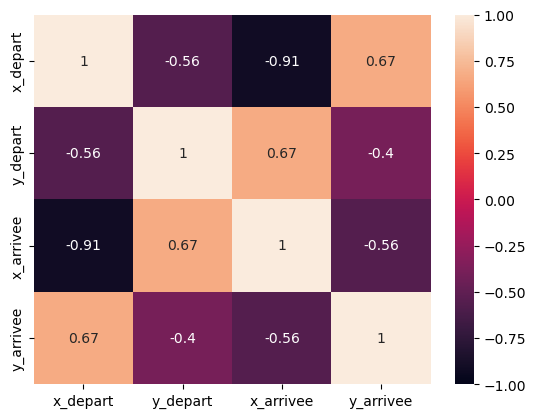

In [22]:
sns.heatmap(dataset_quantitatif_corr,annot=True,vmax=1,vmin=-1)